# Telco Customer Churn — Exploratory Data Analysis

In this notebook I explore the IBM Telco Customer Churn dataset (7,043 customers, 21 columns) to understand the feature types, surface data-quality issues, and form initial hypotheses about what drives a customer to leave.

The target variable is `Churn` (Yes / No).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Loading the data and inspecting the schema

Load the CSV and check the dtypes and null counts with `info()`, followed by a few sample rows with `head()` to confirm the values look sensible.

In [2]:
data = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [3]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### What I see

- Only three columns are numeric out of the box: `SeniorCitizen` (binary 0/1), `tenure` (integer months), and `MonthlyCharges` (float). The other 18 are stored as strings and will need encoding before modeling.
- `customerID` is a unique row identifier with no predictive value, so I'll drop it before modeling.
- `TotalCharges` is the odd one out — its values look numeric in the sample (`29.85`, `1889.5`, …) but the column dtype is `str`. That tells me at least one row contains a value the parser couldn't read as a number.
- `SeniorCitizen` is technically numeric (`int64`) but conceptually it's a binary flag (senior or not) — same shape as `Partner`, `Dependents`, etc. I'll recode it to `'Yes'`/`'No'` in §2 so it joins the categorical block instead of polluting the numeric block.

I dig into the `TotalCharges` issue and apply both fixes in §2.

## 2. Data quality fixes

Three pre-modeling fixes flagged in §1: cast `TotalCharges` to `float`, drop `customerID`, and recode `SeniorCitizen` from `0`/`1` to `'No'`/`'Yes'`. Tackling them in that order.

### 2a. `TotalCharges` is stored as a string

`TotalCharges` values look numeric, but the column dtype is `str`. That means at least one row contains a value the parser couldn't handle. To find them, coerce the column with `errors='coerce'` and pick the rows where the result is NaN:

In [4]:
data[pd.to_numeric(data['TotalCharges'], errors='coerce').isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


### What I found

This returns **11 rows**, all with empty or whitespace strings in `TotalCharges`. They share a tight pattern:

- `tenure == 0` for every one of them, and notably no `tenure == 1` or `2` rows appear in this group.
- `MonthlyCharges` is set — services are configured.
- `Churn == 'No'` across all 11.
- All 11 are on `One year` or `Two year` contracts. None are `Month-to-month`.

These are brand-new customers: they signed up, services were configured, but their first billing cycle hasn't completed yet. The dataset snapshot caught them mid-onboarding. The fact that `tenure=1` rows already have valid `TotalCharges` confirms the story — as soon as the first bill is generated, the column gets a real number. So this isn't really *missing data*; the correct value here is "nothing has been billed yet."

### My fix

**I set `TotalCharges = 0` for these 11 rows and cast the column to `float`.** I considered four alternatives and chose `0` for the following reasons:

1. **It's factually true.** `TotalCharges` means *total amount billed to date*. For a tenure-zero customer that is exactly zero — I'm recording reality, not imputing a value.
2. **It preserves a structural relationship in the data.** `TotalCharges ≈ tenure × MonthlyCharges` for all other rows, so with `tenure = 0` the expected value is `0`. Setting these to `MonthlyCharges` would break that relationship and inject noise.
3. **It keeps a clean signal for downstream models.** A tree model can pick up "tenure=0 → TotalCharges≈0" as a clear marker of brand-new customers.
4. **I'm not dropping the rows** because production data is likely to contain similar fresh-customer cases. The pipeline should handle them, not depend on them being filtered out upstream.
5. **I'm not using NaN** because plain logistic regression doesn't natively handle nulls, and `0` is more faithful to reality here than "unknown."

`pd.to_numeric(..., errors='coerce')` turns the unparseable strings into `NaN`, which `fillna(0)` then replaces with `0`. The same one-liner also gives me `float64` as the new dtype:

In [5]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce').fillna(0)
print(data['TotalCharges'].dtype)

float64


### 2b. Drop `customerID`

`customerID` is a unique row identifier (one customer per row) with no predictive value, so I drop it now to keep it out of any later modeling pipeline by accident.

In [6]:
data = data.drop(columns='customerID')

### 2c. Convert `SeniorCitizen` to a binary `Yes`/`No`

Pandas read `SeniorCitizen` as `int64` because the source CSV stored it as `0`/`1`. But it isn't a numeric quantity — it's a binary flag (senior or not), conceptually identical to `Partner`, `Dependents`, `PhoneService`, etc., which are stored as `'Yes'`/`'No'`.

Treating it as numeric is misleading on two fronts:
1. It would show up in `describe()` and any "numeric features" pipeline alongside `tenure`, `MonthlyCharges`, `TotalCharges` — but `0`/`1` doesn't have a meaningful mean or std the way real continuous variables do.
2. It would get pulled into anything that scales numeric columns (e.g. `StandardScaler`), which would transform a clean binary indicator into an arbitrary float pair like `(-0.45, 2.21)` — same information, but harder for both a human reader and a downstream model to interpret.

I map `0 → 'No'` and `1 → 'Yes'` so it joins the other binary columns in §4 and is one-hot encoded uniformly with them later:

In [7]:
data['SeniorCitizen'] = data['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

## 3. Numeric features

After the §2 fixes (`TotalCharges` cast to float, `SeniorCitizen` recoded to a binary string), the three remaining truly-numeric columns are `tenure`, `MonthlyCharges`, and `TotalCharges`. I check ranges, central tendency, and spread.

In [8]:
data.describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


### What I see

- `tenure` ranges from 0 to 72 months (up to 6 years). Mean ≈ 32, median = 29 — roughly symmetric with mild skew. The min of `0` is the same group of brand-new customers I handled in §2.
- `MonthlyCharges` ranges from \$18.25 to \$118.75. Mean ≈ \$65, median ≈ \$70 — slight left skew. The 25th–75th percentile spread of \$35.50–\$89.85 suggests a fairly wide range of plan tiers.
- `TotalCharges` ranges from \$0 to \$8,684.80. Mean ≈ \$2,280, median ≈ \$1,395 — **heavily right-skewed** (mean is ~1.6× median, and the standard deviation is roughly equal to the mean). That's expected: `TotalCharges` is cumulative, so long-tenure customers pile up large totals while short-tenure customers cluster near zero. This is a strong candidate for a **log transform** if I end up using a linear model.

I'll examine these distributions split by `Churn` in §5 — differences in shape between churners and stayers are usually where modeling signal first shows up.

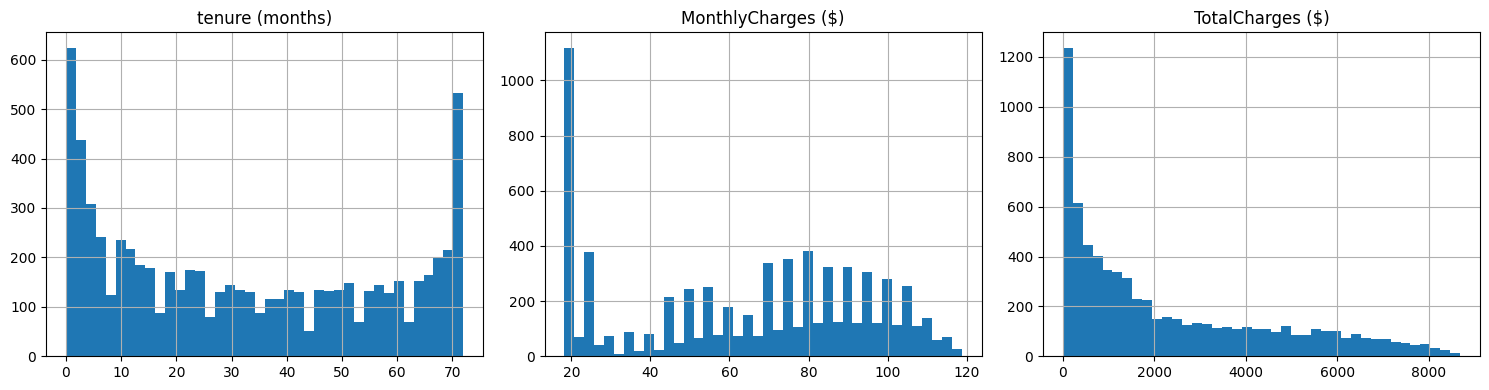

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
data['tenure'].hist(bins=40, ax=axes[0]);          axes[0].set_title('tenure (months)')
data['MonthlyCharges'].hist(bins=40, ax=axes[1]);  axes[1].set_title('MonthlyCharges ($)')
data['TotalCharges'].hist(bins=40, ax=axes[2]);    axes[2].set_title('TotalCharges ($)')
plt.tight_layout()
plt.show()

### What the shapes confirm

`describe()` gives me fingerprints; the histograms confirm the shapes:

- **`tenure`** is **bimodal** — a large spike at low values (recent sign-ups) and another concentration at the high end around 60–72 months (long-stayers). The middle is sparser. This is a strong hint that customer behavior splits into two regimes, and `tenure` will likely be a high-signal feature for churn.
- **`MonthlyCharges`** has a small cluster near \$20 (phone-only or internet-only basic plans) and a much larger mass spread across \$70–\$100 (bundled plans). The slight left skew from `describe()` shows up as that lower hump.
- **`TotalCharges`** is the textbook right-skewed shape — packed against zero with a long tail extending past \$8,000. The bar at exactly `0` is the 11 brand-new customers from §2.

The bimodality of `tenure` is the most interesting finding here — it suggests the question *"does this customer churn?"* might be largely answered by *which mode* the customer sits in. That's exactly the kind of thing the bivariate analysis (§5 step 4) should expose.

## 4. Categorical features

For each non-numeric column, I list the distinct values. The goal is to spot:

- columns that look binary but secretly have a third level
- inconsistent capitalization or whitespace
- cardinality high enough that one-hot encoding would blow up the feature space

In [10]:

cols = ['gender', 'SeniorCitizen','Partner','Dependents','PhoneService','MultipleLines','InternetService','OnlineSecurity','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaperlessBilling','PaymentMethod','Churn']  # your specific columns

for col in cols:
    print(f"{col}: {data[col].unique().tolist()}")

gender: ['Female', 'Male']
SeniorCitizen: ['No', 'Yes']
Partner: ['Yes', 'No']
Dependents: ['No', 'Yes']
PhoneService: ['No', 'Yes']
MultipleLines: ['No phone service', 'No', 'Yes']
InternetService: ['DSL', 'Fiber optic', 'No']
OnlineSecurity: ['No', 'Yes', 'No internet service']
DeviceProtection: ['No', 'Yes', 'No internet service']
TechSupport: ['No', 'Yes', 'No internet service']
StreamingTV: ['No', 'Yes', 'No internet service']
StreamingMovies: ['No', 'Yes', 'No internet service']
Contract: ['Month-to-month', 'One year', 'Two year']
PaperlessBilling: ['Yes', 'No']
PaymentMethod: ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']
Churn: ['No', 'Yes']


### What I see

Most categorical columns are clean binaries (`Yes`/`No`) or low-cardinality (3–4 levels), so encoding will be straightforward. But seven columns encode "service unavailable" as a *third* category instead of being true binaries:

| Column | Levels |
|---|---|
| `MultipleLines` | `No phone service`, `No`, `Yes` |
| `InternetService` | `DSL`, `Fiber optic`, `No` |
| `OnlineSecurity` | `No internet service`, `No`, `Yes` |
| `OnlineBackup` | `No internet service`, `No`, `Yes` |
| `DeviceProtection` | `No internet service`, `No`, `Yes` |
| `TechSupport` | `No internet service`, `No`, `Yes` |
| `StreamingTV` | `No internet service`, `No`, `Yes` |
| `StreamingMovies` | `No internet service`, `No`, `Yes` |

The `No internet service` and `No phone service` values aren't independent information — they're *fully determined* by `InternetService == 'No'` and `PhoneService == 'No'` respectively. If I one-hot encode naively, this redundancy creates perfectly collinear features. Multicollinearity inflates coefficient variance in a logistic regression, while a tree-based model is largely indifferent to it.

**My plan: collapse `No internet service` → `No` (and `No phone service` → `No`) before encoding.** This treats "I don't have the parent service" the same as "I have the parent service but don't use this add-on" — both states mean "this feature is not active for this customer," which is the assumption I want the model to learn.

`PaymentMethod` has the highest cardinality at 4 levels — still small enough to one-hot directly without any risk of feature explosion.

## 4a. Target class balance

Before bivariate analysis, I check the distribution of the target itself. The Yes/No ratio determines which evaluation metrics make sense — accuracy is misleading under heavy imbalance.

In [11]:
data['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

### What I see

The dataset is **moderately imbalanced**: 73.5% Stayed (`No`) vs **26.5% Churned (`Yes`)**. Implications:

- The minority class (`Yes`) is the one I actually care about predicting — accuracy will be misleading, since a naive "always predict No" model would score 73.5% accuracy without learning anything.
- I'll use **F1** as the primary metric (balances precision and recall on the positive class) and **ROC-AUC** as a secondary, threshold-independent ranking metric. I may revisit PR-AUC after seeing baseline numbers, since it's typically more informative than ROC-AUC when the positive class is small.
- For train/test splitting, I'll use **`stratify=Churn`** so the 26.5% ratio is preserved in both folds — otherwise random splits could distort the class balance enough to shift evaluation numbers.

## 5. Bivariate analysis — features vs `Churn`

The univariate views above tell me what each feature looks like on its own. To find modeling signal, I compare each feature across the two classes (`Churn = Yes` vs `Churn = No`). The plot type depends on the feature type:

- **Numeric features** (`tenure`, `MonthlyCharges`): two overlapping histograms — one per class — on the same axis. If the two distributions are noticeably different, the feature has signal.
- **Categorical features** (`Contract`, `PaymentMethod`): a bar chart of *churn rate within each level*, with a horizontal reference line at the overall 26.5% baseline. Levels above the line are higher-churn segments; levels below it are stickier.

Visual recap of the class balance from §4a, then the four bivariate plots:

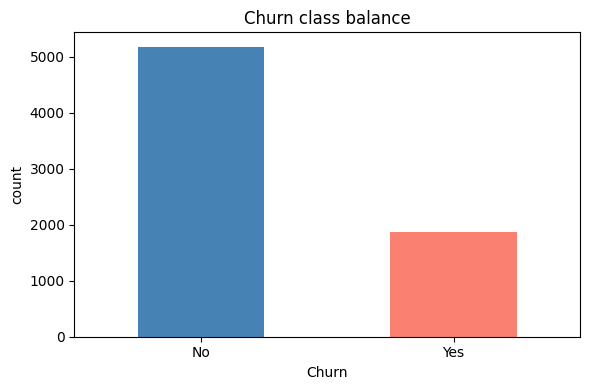

In [12]:
ax = data['Churn'].value_counts().plot(kind='bar', figsize=(6, 4), color=['steelblue', 'salmon'])
ax.set_ylabel('count')
ax.set_title('Churn class balance')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

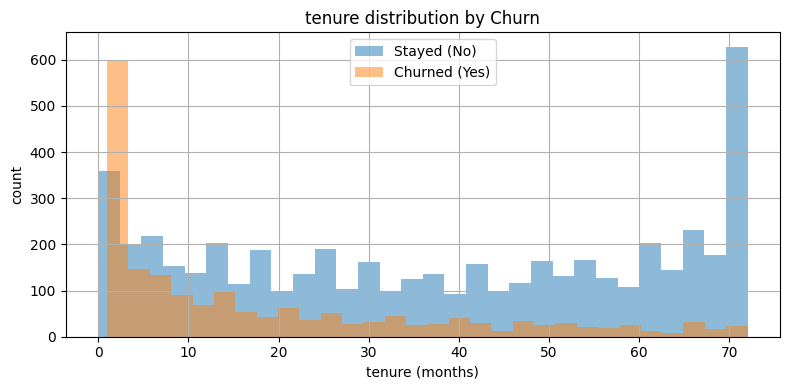

In [13]:
# Numeric feature split by Churn — example: tenure
# Pattern: filter rows for each class, plot two overlapping histograms on the same axis.
# alpha=0.5 makes both visible where they overlap.

fig, ax = plt.subplots(figsize=(8, 4))
data[data['Churn'] == 'No']['tenure'].hist(bins=30, alpha=0.5, label='Stayed (No)', ax=ax)
data[data['Churn'] == 'Yes']['tenure'].hist(bins=30, alpha=0.5, label='Churned (Yes)', ax=ax)
ax.set_xlabel('tenure (months)')
ax.set_ylabel('count')
ax.set_title('tenure distribution by Churn')
ax.legend()
plt.tight_layout()
plt.show()

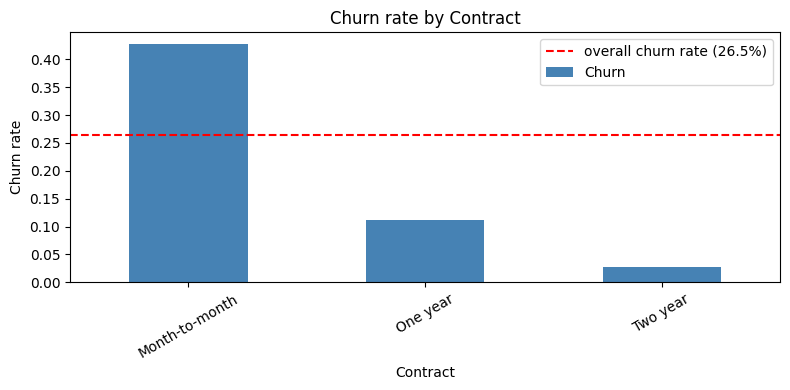

In [14]:
# Categorical feature split by Churn — example: Contract
# Pattern: compute churn RATE within each level, then bar chart it.
# .groupby(col)['Churn'] groups rows by the categorical column;
# .apply(lambda x: (x == 'Yes').mean()) computes the share of 'Yes' (= churn rate) inside each group.

churn_rate_contract = data.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean())
ax = churn_rate_contract.plot(kind='bar', figsize=(8, 4), color='steelblue')
ax.set_ylabel('Churn rate')
ax.set_title('Churn rate by Contract')
ax.axhline(0.265, color='red', linestyle='--', label='overall churn rate (26.5%)')
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

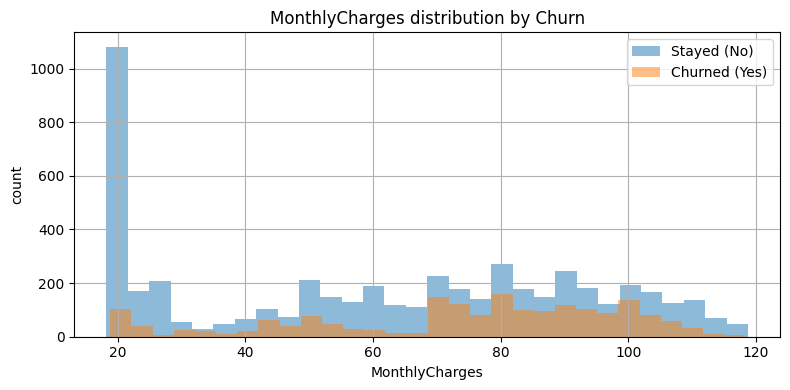

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
data[data['Churn'] == 'No']['MonthlyCharges'].hist(bins=30, alpha=0.5, label='Stayed (No)', ax=ax)
data[data['Churn'] == 'Yes']['MonthlyCharges'].hist(bins=30, alpha=0.5, label='Churned (Yes)', ax=ax)
ax.set_xlabel('MonthlyCharges')
ax.set_ylabel('count')
ax.set_title('MonthlyCharges distribution by Churn')
ax.legend()
plt.tight_layout()
plt.show()

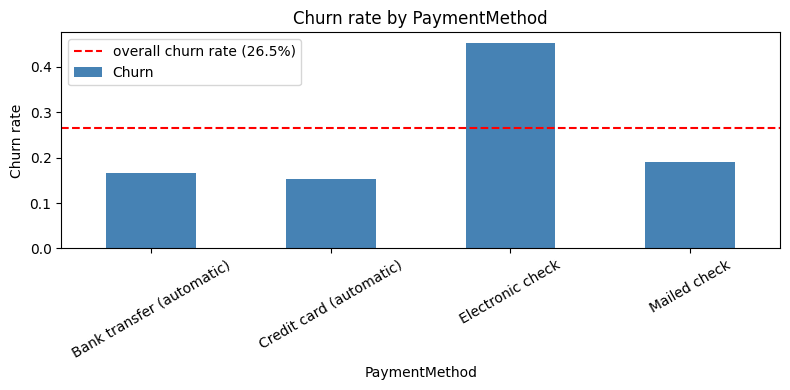

In [16]:
churn_rate_contract = data.groupby('PaymentMethod')['Churn'].apply(lambda x: (x == 'Yes').mean())
ax = churn_rate_contract.plot(kind='bar', figsize=(8, 4), color='steelblue')
ax.set_ylabel('Churn rate')
ax.set_title('Churn rate by PaymentMethod')
ax.axhline(0.265, color='red', linestyle='--', label='overall churn rate (26.5%)')
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### What I see in the bivariate plots

- **`tenure` × `Churn` (numeric).** Strong signal. The Churned distribution is heavily front-loaded — a sharp spike of ~600 customers at `tenure = 1–2` months, decaying steadily until around month 30, then going nearly flat. The Stayed distribution is the inverse: relatively flat through the early months, then a large peak at `tenure = 70+` where ~640 long-stayers cluster. **Read:** new customers churn aggressively; long-tenure customers almost never do. This is the bimodality I noticed in §3 showing up cleanly when split by the target.
- **`Contract` × `Churn` (categorical).** Very strong signal. `Month-to-month` customers churn at ~42%, well above the 26.5% overall baseline. The rate drops sharply with contract length — `One year` and `Two year` both sit far below baseline. **Read:** contract length is likely one of the strongest single-feature predictors in this dataset.
- **`MonthlyCharges` × `Churn` (numeric) — mixed signal with a methodological caveat.** At low charges (~\$20) the population is overwhelmingly Stayed (~1,100 stayers vs ~100 churners) — basic-plan customers tend not to leave. In the \$70–\$110 band the two distributions overlap heavily with comparable counts on each side. At very high charges (\$110+) total counts shrink simply because fewer customers sit there.
  > **Caveat.** Overlapping histograms show *counts*, not *rates*. The fact that the upper tail "looks like fewer churners" is partly just thinning data — churn *rate* (proportion) at high MonthlyCharges may still be moderate or high. To answer that properly I'd bin `MonthlyCharges` and plot churn proportion per bin (same pattern as the categorical plots). Adding this as a follow-up.
- **`PaymentMethod` × `Churn` (categorical).** Strong signal. `Electronic check` customers churn at >40%, well above baseline. `Bank transfer (automatic)` and `Credit card (automatic)` sit at the lowest churn rates. **Read:** automatic payment methods correlate with retention; `Electronic check` stands out as a clear churn marker.

### Hypotheses going into modeling

Three features stand out as primary churn predictors based on this view: **short `tenure`**, **`Month-to-month Contract`**, and **`Electronic check` `PaymentMethod`**. `MonthlyCharges` carries some signal at the low end but needs a rate-based follow-up to fully characterize. A baseline `LogisticRegression` using these features should comfortably beat the naive 73.5% always-No accuracy.

## 6. Next steps

The work above gets me to the point where I understand what each column represents, where the data-quality landmines are, and which features visibly carry churn signal. The actual modeling questions come next:

1. **Encoding strategy.** Apply the `No internet/phone service → No` collapse from §4, then one-hot the rest. `customerID` is already dropped.
2. **Train/test split** with `stratify=Churn` to preserve class balance, then fit a baseline `LogisticRegression`. Report accuracy, precision, recall, F1, ROC-AUC, confusion matrix.
3. **Cross-validate** with `StratifiedKFold` + `Pipeline` (scaler + model). Compare CV numbers to single-split.
4. **Iterate** with feature engineering (log-transform `TotalCharges` per §3 observation, tenure buckets per the bimodality finding, etc.) and try tree-based models (Random Forest, XGBoost) for comparison.

I'll address these in `02-baseline-logistic-regression.ipynb` and `03-cross-validated-baseline.ipynb`.